### Program Name: Exponential Growth Model: Numerical Solution
#### Author: C.D. Wentworth + Johang Hernandez
*version: 3.18.2026.1*

> Summary: Basic script for solving a dynamical system representing
         exponential growth. A numerical integration technique is
         used. A scatter plot of bacterial growth data is included on the graph and the exponential line is fitted manually.

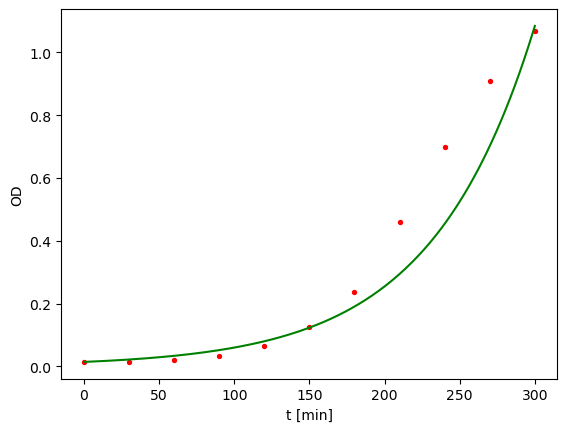

In [22]:
import scipy.integrate as si
import numpy as np
import matplotlib.pylab as plt

def f(t,y,r):
#   y = a list that contains the system state
#   t = the time for which the right-hand-side of the system equations
#       is to be calculated.
#   r = a parameter needed for the model
#
    import numpy as np

#   Unpack the state of the system
    y0 = y[0] # cell density 

#   Calculate the rates of change (the derivatives)
    dy0dt = r*y0

    return [dy0dt]

# Main Program

# Define the initial conditions
N0 = [0.014]

# Define the time grid
t = np.linspace(0,300,200)

# Define the model parameters
r = 0.0145
p = (r,)

# Solve the DE
sol = si.solve_ivp(f,(0,300),N0,t_eval=t,args=p)
N = sol.y[0]

# Plot the datapoints

# read the data
df = np.loadtxt("BacterialGrowthData.txt", skiprows=9)

plt.scatter(df[:, 0], df[:, 2], c="red", s=8)

# Plot the theory
plt.plot(t,N,color='g')
plt.xlabel('t [min]')
plt.ylabel('OD')
plt.savefig('ExponentialGrowth.png',dpi=300)
plt.show()
